In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

import src.data as data
import src.indicators as indicators
import src.strategies as strategies
import src.plots as plots
from src.backtesting_engine import bactester, compute_buy_hold_benchmark

# Data

In [4]:
btc = data.fetch_ohlcv_full("BTC/USDT")
eth = data.fetch_ohlcv_full("ETH/USDT")

In [5]:
btc , btc_invals  = data.clean_and_validate_crypto(btc, ticker_label="BTC-USD")
eth , eth_invals  = data.clean_and_validate_crypto(eth, ticker_label="ETH-USD")

=== Data Cleaning Report: BTC-USD ===
Zero-Volume Bars Found:     0
Invalid OHLC Bars Found:    0
------------------------------------------
=== Data Cleaning Report: ETH-USD ===
Zero-Volume Bars Found:     0
Invalid OHLC Bars Found:    0
------------------------------------------


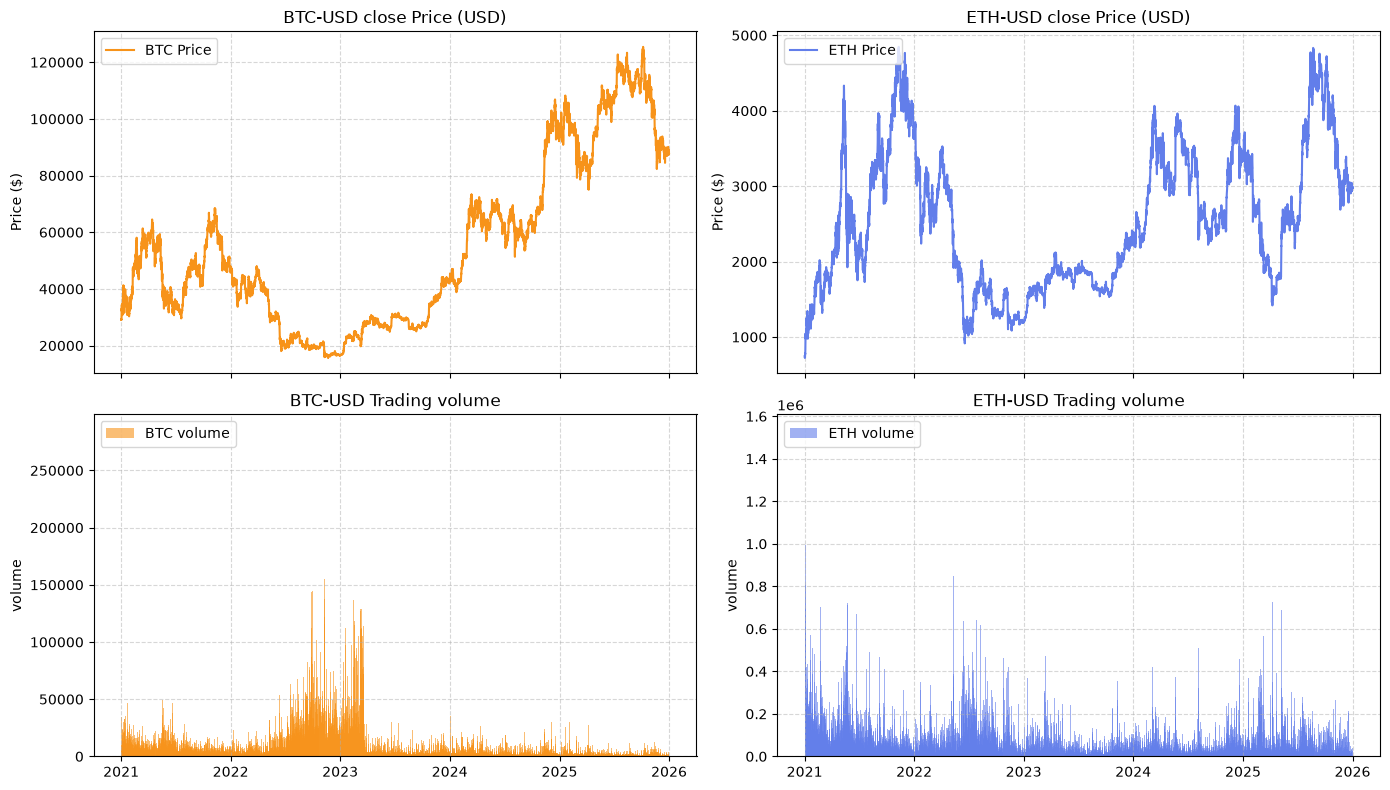

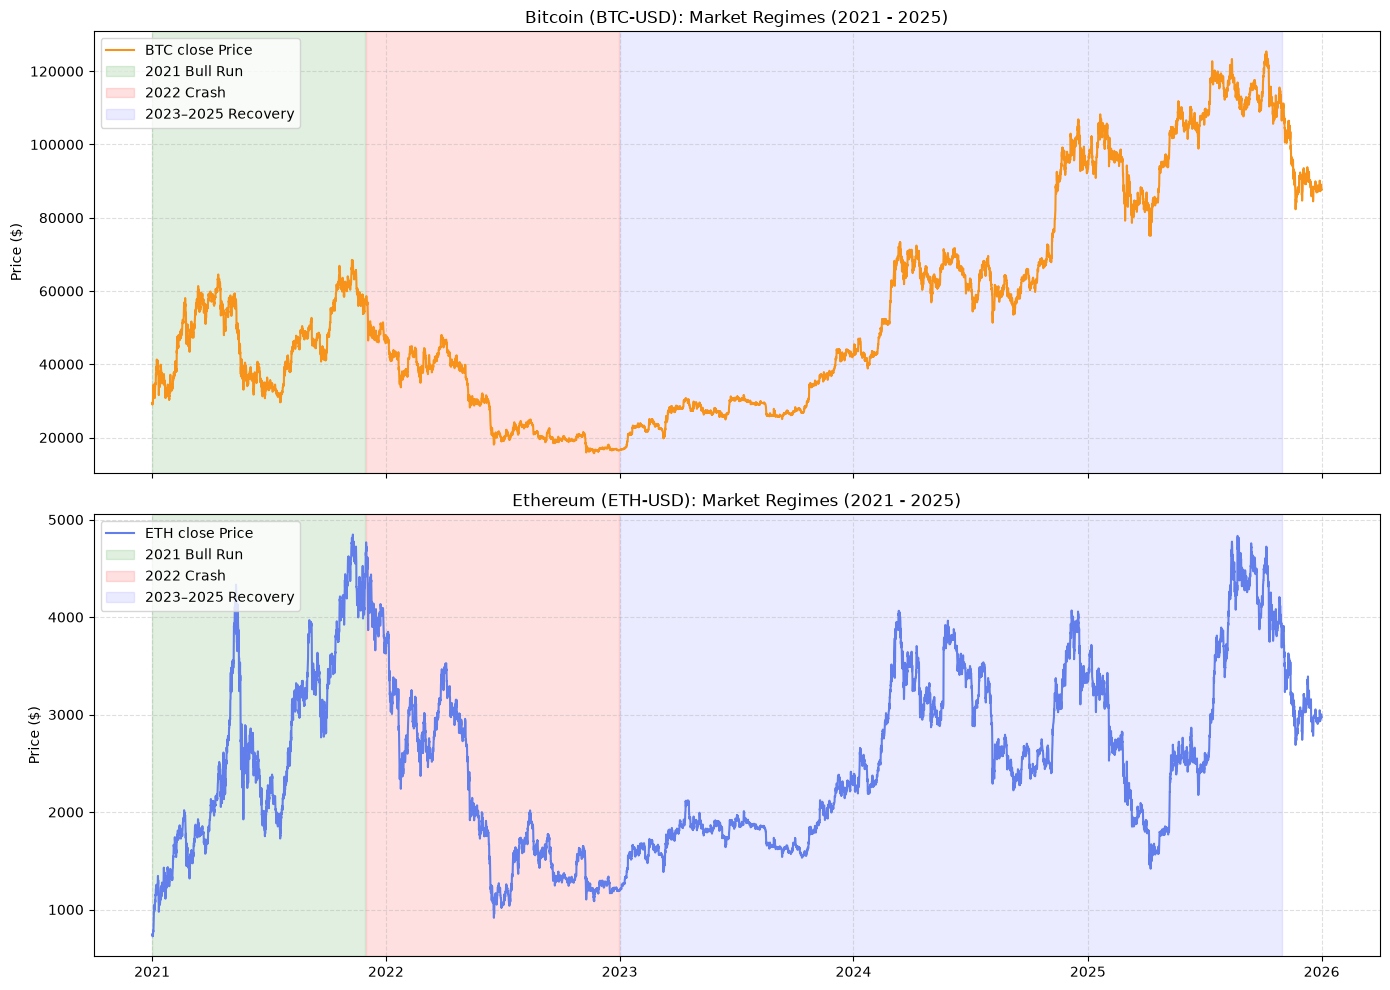

In [6]:
plots.plot_price_volume(btc, eth)
plots.plot_regimes(btc, eth)

In [7]:
btc_23 = btc.loc[:"2023-12-31"]
eth_23 = eth.loc[:"2023-12-31"]

assets = {"BTC": btc_23, "ETH": eth_23}

start_capital = 100000.00
periods = 6*365

# Benchmark

In [8]:
results = {}

for name, df in assets.items():
    results[("buy_hold", name)] = compute_buy_hold_benchmark(df, periods=periods, start_capital=start_capital)

d:\Ayushkumar Singh\Programming\Quant\INTERIITBOOTCAMP\final_directory\src\backtesting_engine.py:73: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quarterly = (1 + net).groupby(net.index.to_period('Q')).prod() - 1


# Metrics

Return autocorrelation

BTC 0.024674440339920178
[ 1.         -0.03390664  0.01630509  0.04024496 -0.0179592  -0.01003808
 -0.05096689 -0.00606296  0.01577775 -0.00740697  0.01492862  0.01653046
 -0.02213346  0.00354851  0.00231153  0.02172714  0.00397713  0.00339946
 -0.0031302  -0.04264947  0.00651961 -0.00623514 -0.00381675  0.03205489
 -0.01789725  0.01461751  0.03628294 -0.00344575  0.0026603   0.00780263
  0.02010858 -0.00330371 -0.0254616  -0.0179692   0.0211089   0.03228754
 -0.00271292 -0.01597153  0.01862147]


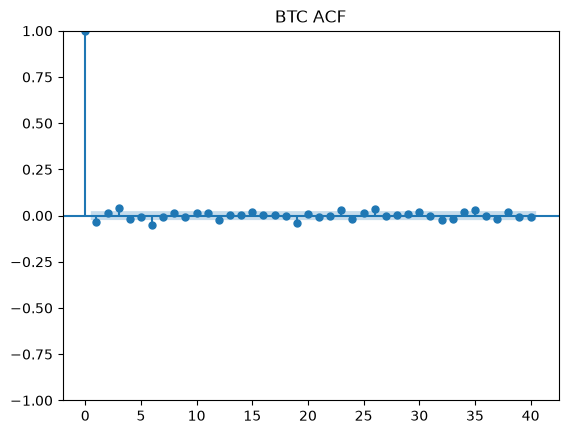

ETH 0.024674440339920178
[ 1.         -0.03833721  0.03035041  0.0249928  -0.01823611 -0.00240865
 -0.04502311 -0.01101632  0.00218998  0.01057593  0.0166656   0.03389069
 -0.0020049  -0.00971538  0.00458132  0.00133941  0.00238359  0.01056624
  0.00445075 -0.03852453  0.01101914  0.01247268  0.00777758  0.02477217
 -0.0286831   0.00763388  0.0196634  -0.02229111 -0.00912228  0.01493963
  0.00172932 -0.02109509 -0.02196759  0.00271048  0.04146411  0.02175638
  0.03783567 -0.02858552  0.02902949]


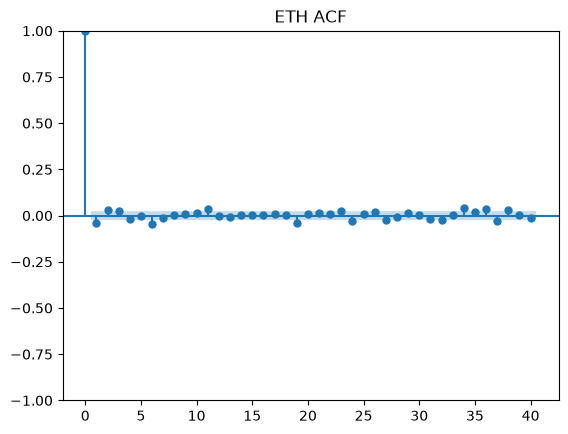

In [9]:
lag_window = 50

for name, df in assets.items():
    returns = df.close.pct_change().dropna()
    print(name, 2/np.sqrt(len(df)))
    print(acf(returns, lag_window))
    plot_acf(returns, lags=40, title=f"{name} ACF")
    plt.show()

Variance ratio

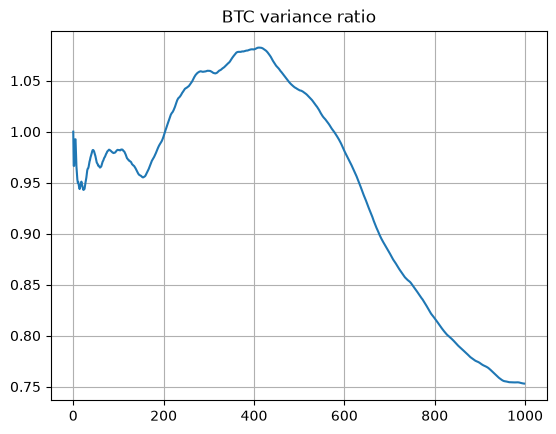

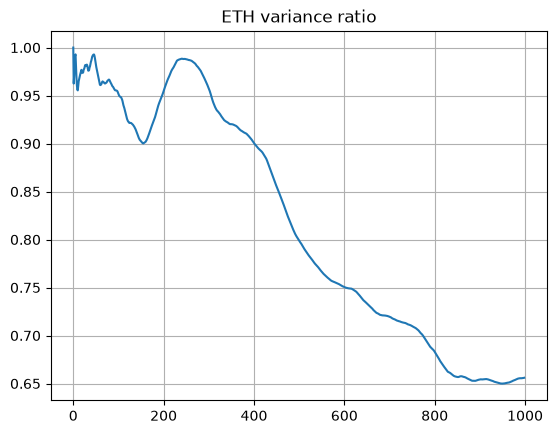

In [10]:
for name, df in assets.items():
    var_ratio = [indicators.variance_ratio(df, win) for win in range(1,1000)]
    plt.grid(True)
    plt.plot(var_ratio)
    plt.title(f"{name} variance ratio")
    plt.show()

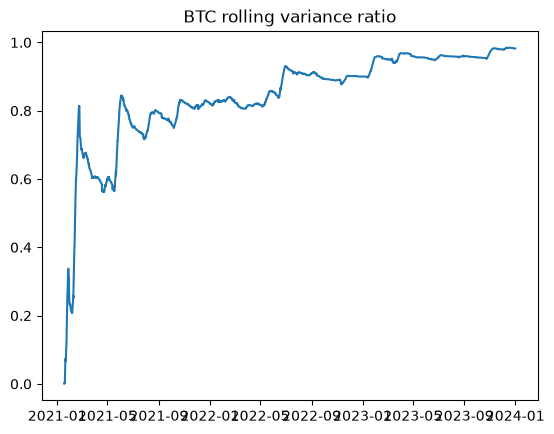

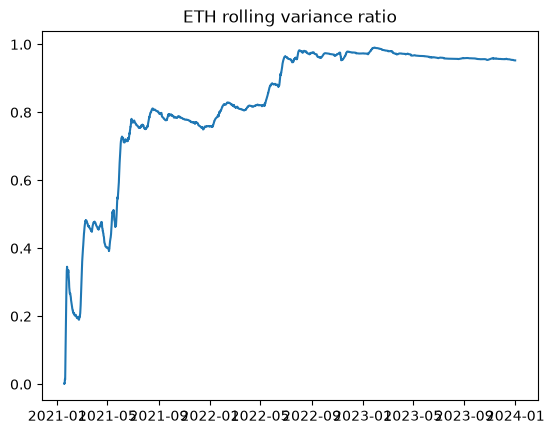

In [11]:
for name, df in assets.items():
    rollingvr = indicators.rolling_vr(df, 100)
    plt.plot(rollingvr)
    plt.title(f"{name} rolling variance ratio")
    plt.show()

ADX

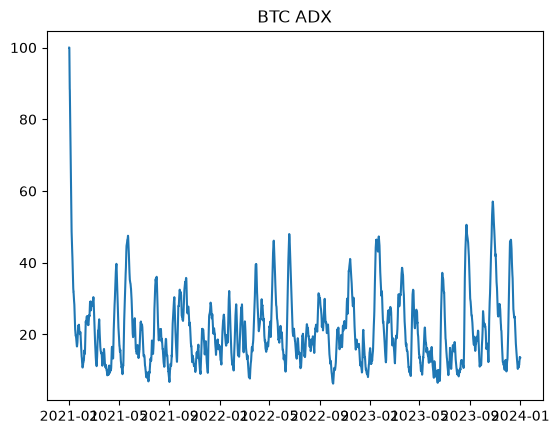

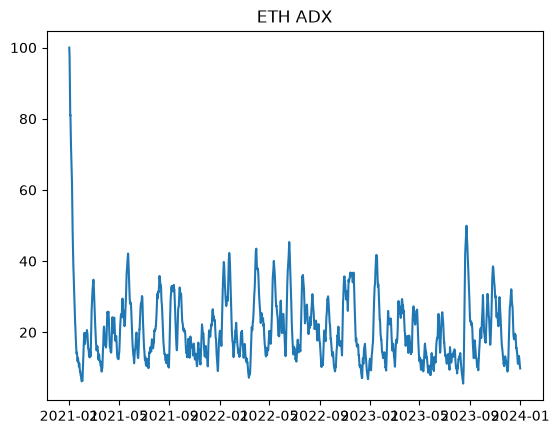

In [12]:
for name, df in assets.items():
    plt.plot(indicators.adx(df, 30).adx)
    plt.title(f"{name} ADX")
    plt.show()

# Models

Mean reversion, MA crossover

In [13]:
models = {
    "mean_reversion": strategies.mean_reversion,
    "ma_crossover": strategies.ma_crossover,
}

for model_name, model in models.items():
    for name, df in assets.items():
        results[(model_name, name)] = bactester(df, signals=model(df), start_capital=start_capital, periods=periods)

Random signals

In [14]:
for name, df in assets.items():
    signals = pd.Series(
        np.random.choice([0,-1,1], size=len(df)),
        index = df.index
    )
    results[("random", name)] = bactester(df, signals, start_capital, periods)

# Results

In [15]:
keys = ["net_profit", "total_return", "sharpe", "sortino", "max_drawdown", "n_trades"]

pd.DataFrame({k: {m: r[m] for m in keys} for k, r in results.items()}).T

net_profit  total_return    sharpe   sortino  \
buy_hold       BTC   43984.377435      0.439844  0.514456  0.735109   
               ETH  205444.283635      2.054443  0.863739  1.233851   
mean_reversion BTC  -83868.328694     -0.838683 -2.150878 -2.900974   
               ETH  -80106.068268     -0.801061 -1.388637 -1.929388   
ma_crossover   BTC  -47479.024688     -0.474790 -0.196294 -0.279712   
               ETH   10718.240473      0.107182  0.372899  0.533772   
random         BTC  -99988.852940     -0.999889 -5.298125 -6.918875   
               ETH  -99998.686701     -0.999987 -5.043537 -6.534168   

                    max_drawdown  n_trades  
buy_hold       BTC     -0.770434       2.0  
               ETH     -0.811181       2.0  
mean_reversion BTC     -0.885677    1073.0  
               ETH     -0.859927    1074.0  
ma_crossover   BTC     -0.651994     276.0  
               ETH     -0.689512     278.0  
random         BTC     -0.999908    4394.0  
               ETH     -0.999987    4334.0